# Imports & Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
import seaborn as sns
import time

Load Dataset from TensorFlow

In [16]:
# Load MNIST directly from tensorflow.keras.datasets
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Train shape:", x_train.shape, y_train.shape)
print("Test shape:", x_test.shape, y_test.shape)

Train shape: (60000, 28, 28) (60000,)
Test shape: (10000, 28, 28) (10000,)


Visualize Some Samples

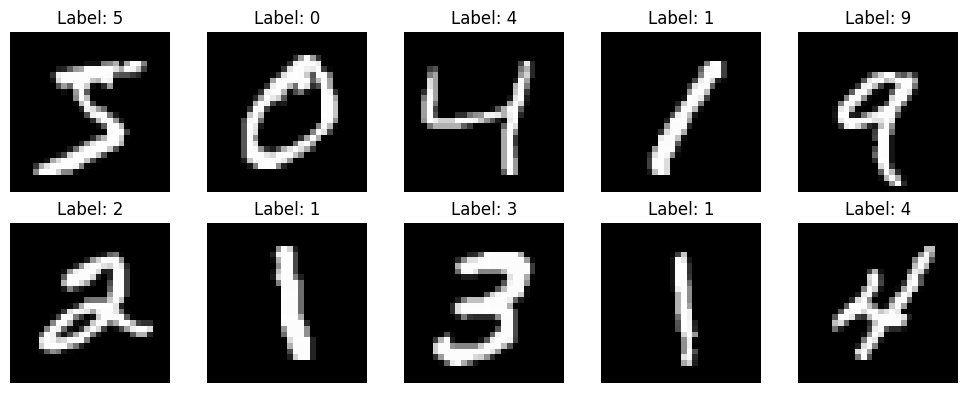

In [3]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

# Preprocess Data

In [4]:
# Flatten 28x28 images into 784-length vectors
x_train_flat = x_train.reshape(x_train.shape[0], -1)
x_test_flat = x_test.reshape(x_test.shape[0], -1)

# Normalize pixel values to 0-1
x_train_flat = x_train_flat.astype('float32') / 255.0
x_test_flat = x_test_flat.astype('float32') / 255.0

# KNN is slow on 60k x 784 dims — use a subset for speed
# You can increase these if you have time/patience
N_TRAIN = 10000
N_TEST = 2000

x_train_small = x_train_flat[:N_TRAIN]
y_train_small = y_train[:N_TRAIN]
x_test_small = x_test_flat[:N_TEST]
y_test_small = y_test[:N_TEST]

print("Using train:", x_train_small.shape, " test:", x_test_small.shape)

Using train: (10000, 784)  test: (2000, 784)


# (Optional / recommended) Speed up with PCA

In [22]:
# Reduce 784 dims to ~50 principal components — big speedup, minimal accuracy loss
pca = PCA(n_components=100, random_state=42)
x_train_pca = pca.fit_transform(x_train_small)
x_test_pca = pca.transform(x_test_small)

print("Explained variance retained:", sum(pca.explained_variance_ratio_))

Explained variance retained: 0.91686046


# Train KNN Classifier

In [23]:
k = 5
knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)

start = time.time()
knn.fit(x_train_pca, y_train_small)
print(f"Training took {time.time() - start:.2f} seconds")

Training took 0.00 seconds


# Evaluate

In [24]:
start = time.time()
y_pred = knn.predict(x_test_pca)
print(f"Prediction took {time.time() - start:.2f} seconds")

acc = accuracy_score(y_test_small, y_pred)
print(f"Accuracy: {acc * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test_small, y_pred))

Prediction took 0.23 seconds
Accuracy: 93.10%

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.97       175
           1       0.91      1.00      0.96       234
           2       0.99      0.90      0.95       219
           3       0.91      0.93      0.92       207
           4       0.95      0.92      0.93       217
           5       0.93      0.92      0.92       179
           6       0.93      0.97      0.95       178
           7       0.90      0.91      0.91       205
           8       0.96      0.84      0.90       192
           9       0.89      0.92      0.91       194

    accuracy                           0.93      2000
   macro avg       0.93      0.93      0.93      2000
weighted avg       0.93      0.93      0.93      2000



# Confusion Matrix

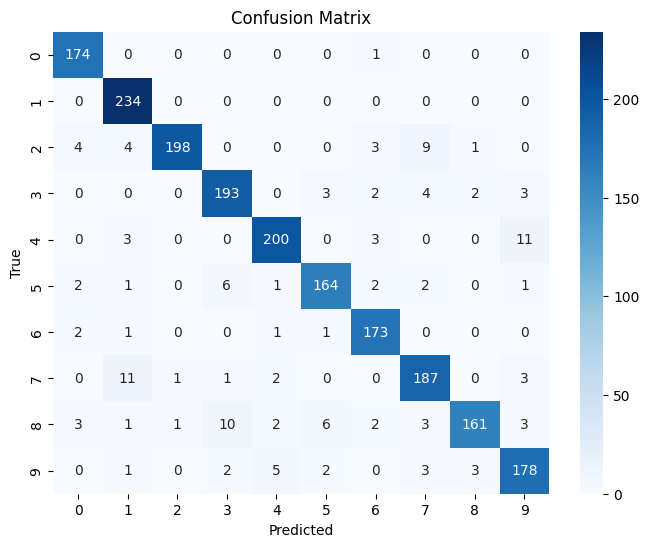

In [25]:
cm = confusion_matrix(y_test_small, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Test on Custom Samples & Visualize Predictions

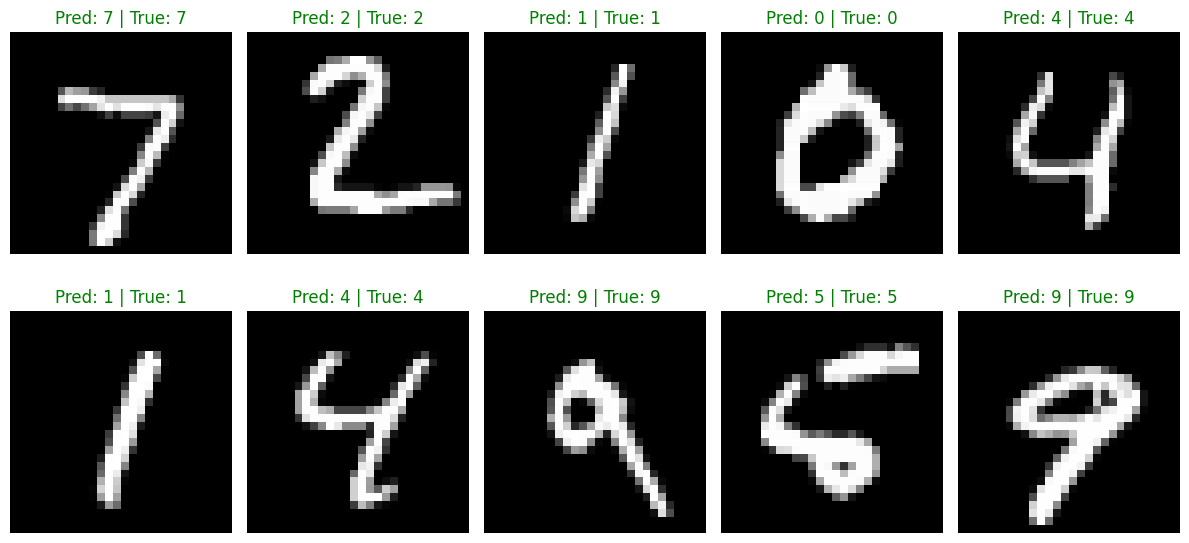

In [26]:
plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test_small[i].reshape(28, 28), cmap='gray')
    color = 'green' if y_pred[i] == y_test_small[i] else 'red'
    plt.title(f"Pred: {y_pred[i]} | True: {y_test_small[i]}", color=color)
    plt.axis('off')
plt.tight_layout()
plt.show()

# Find Best K Value

k=1: accuracy=93.50%
k=3: accuracy=93.10%
k=5: accuracy=93.10%
k=7: accuracy=93.00%
k=9: accuracy=92.70%
k=11: accuracy=92.30%


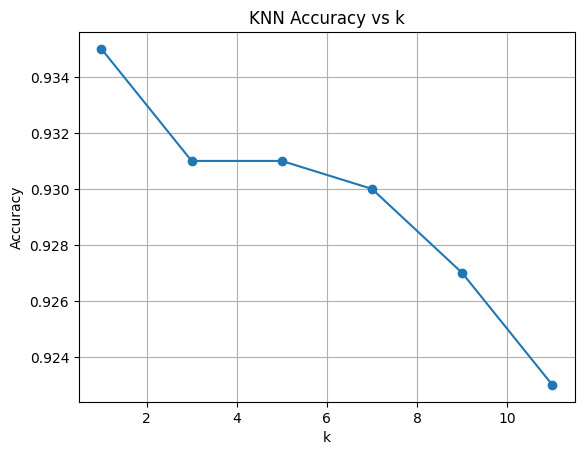

In [27]:
k_values = [1, 3, 5, 7, 9, 11]
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    model.fit(x_train_pca, y_train_small)
    pred = model.predict(x_test_pca)
    acc = accuracy_score(y_test_small, pred)
    accuracies.append(acc)
    print(f"k={k}: accuracy={acc*100:.2f}%")

plt.plot(k_values, accuracies, marker='o')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy vs k')
plt.grid(True)
plt.show()

# Visualize How KNN Actually Decides (Nearest Neighbors Explained)

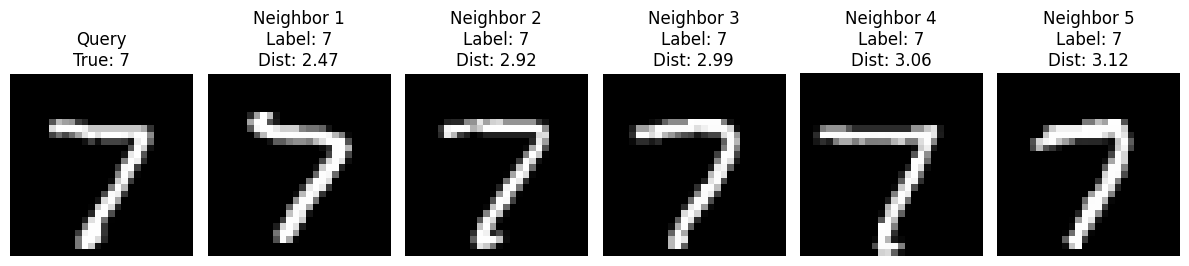

This is literally how KNN decides: it looks at the 'k' closest training
images (by distance) and picks the most common label among them.


In [11]:
# Pick one test image and show its "k nearest neighbors" from training data
sample_idx = 0
sample_image = x_test_pca[sample_idx].reshape(1, -1)

distances, indices = knn.kneighbors(sample_image, n_neighbors=5)

plt.figure(figsize=(12, 3))

# Show the query image first
plt.subplot(1, 6, 1)
plt.imshow(x_test_small[sample_idx].reshape(28, 28), cmap='gray')
plt.title(f"Query\nTrue: {y_test_small[sample_idx]}")
plt.axis('off')

# Show its 5 nearest neighbors
for i, idx in enumerate(indices[0]):
    plt.subplot(1, 6, i + 2)
    plt.imshow(x_train_small[idx].reshape(28, 28), cmap='gray')
    plt.title(f"Neighbor {i+1}\nLabel: {y_train_small[idx]}\nDist: {distances[0][i]:.2f}")
    plt.axis('off')

plt.tight_layout()
plt.show()
print("This is literally how KNN decides: it looks at the 'k' closest training")
print("images (by distance) and picks the most common label among them.")

# Show Why Distance Metric/Normalization Matters

In [12]:
# Compare accuracy with vs without normalization
x_train_unnorm = x_train[:N_TRAIN].reshape(N_TRAIN, -1).astype('float32')  # 0-255 range
x_test_unnorm = x_test[:N_TEST].reshape(N_TEST, -1).astype('float32')

knn_unnorm = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn_unnorm.fit(x_train_unnorm, y_train_small)
acc_unnorm = accuracy_score(y_test_small, knn_unnorm.predict(x_test_unnorm))

print(f"Accuracy WITHOUT normalization (0-255): {acc_unnorm*100:.2f}%")
print(f"Accuracy WITH normalization (0-1):      {acc*100:.2f}%")
print("\nNote: for pixel data both usually work similarly since all features share")
print("the same scale — but with mixed-scale features, normalization matters a lot!")

Accuracy WITHOUT normalization (0-255): 92.05%
Accuracy WITH normalization (0-1):      93.20%

Note: for pixel data both usually work similarly since all features share
the same scale — but with mixed-scale features, normalization matters a lot!


# TODO Exercise

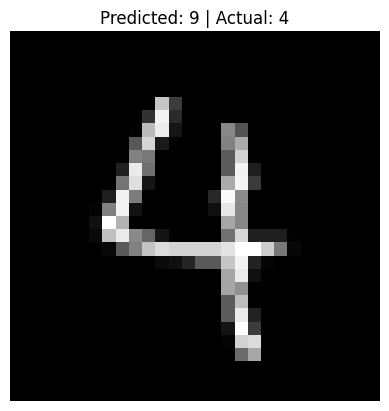

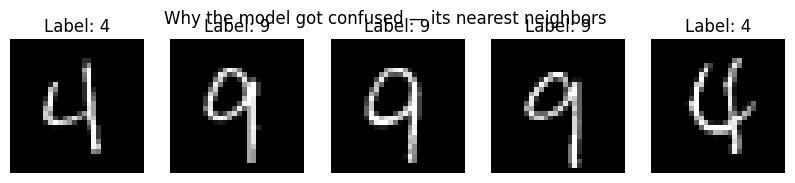

In [13]:
# Find and inspect a mistake — helps learners see WHY the model got confused
wrong_indices = np.where(y_pred != y_test_small)[0]

if len(wrong_indices) > 0:
    idx = wrong_indices[0]
    plt.imshow(x_test_small[idx].reshape(28, 28), cmap='gray')
    plt.title(f"Predicted: {y_pred[idx]} | Actual: {y_test_small[idx]}")
    plt.axis('off')
    plt.show()

    # Show its neighbors too, so learners see why it was confused
    distances, indices = knn.kneighbors(x_test_pca[idx].reshape(1, -1), n_neighbors=5)
    plt.figure(figsize=(10, 2))
    for i, n_idx in enumerate(indices[0]):
        plt.subplot(1, 5, i + 1)
        plt.imshow(x_train_small[n_idx].reshape(28, 28), cmap='gray')
        plt.title(f"Label: {y_train_small[n_idx]}")
        plt.axis('off')
    plt.suptitle("Why the model got confused — its nearest neighbors")
    plt.show()
else:
    print("No misclassifications in this test set — try a larger N_TEST!")

self check
